### Click-Through Rate Prediction - Exploratory Data Analysis
# 
#### **Author**: Praveen Kumar  
#### **Date**: September 2026
# 
#### This notebook performs comprehensive EDA on the ad click dataset.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
# Set styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# Load the dataset
try:
    df = pd.read_csv('../data/click_data.csv')
except:
    # Generate synthetic dataset if file doesn't exist
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=10000, n_features=8, n_informative=6, 
                               n_redundant=2, random_state=42)
    df = pd.DataFrame(X, columns=['Age', 'Income', 'Time_on_Site', 'Previous_Clicks', 
                                  'Device_Type', 'Ad_Category', 'Gender', 'Time_of_Day'])
    df['Clicked'] = y
    # Clean and transform for realistic values
    df['Age'] = np.clip(df['Age'] * 20 + 30, 18, 65).astype(int)
    df['Income'] = np.clip(df['Income'] * 30000 + 40000, 20000, 150000).astype(int)
    df['Time_on_Site'] = np.clip(df['Time_on_Site'] * 5 + 5, 0, 30).round(1)
    df['Previous_Clicks'] = np.clip(df['Previous_Clicks'] * 10 + 5, 0, 50).astype(int)
    df['Device_Type'] = np.where(df['Device_Type'] > 0.5, 'Mobile', 'Desktop')
    df['Ad_Category'] = np.where(df['Ad_Category'] > 0.5, 'Technology', 'Lifestyle')
    df['Gender'] = np.where(df['Gender'] > 0.5, 'Male', 'Female')
    df['Time_of_Day'] = np.where(df['Time_of_Day'] > 0.5, 'Evening', 'Morning')
    
    # Save for future use
    import os
    os.makedirs('../data', exist_ok=True)
    df.to_csv('../data/click_data.csv', index=False)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 9)


,Age,Income,Time_on_Site,Previous_Clicks,Device_Type,Ad_Category,Gender,Time_of_Day,Clicked
0,-0.270336,-1.067872,1.723546,-3.414406,0.031394,-1.269845,3.612138,2.761570,1
1,1.417750,-2.044457,2.360961,-0.057302,-1.798305,0.801589,1.666972,0.961546,0
2,-0.250326,-0.996390,-2.254302,2.339306,-0.119648,-0.402036,-1.361081,-0.491140,0
3,-1.350838,0.698667,2.210836,-4.490122,-0.034687,-1.723581,3.160316,1.134817,1
4,-0.749040,-0.832755,-0.287085,1.682244,-3.172607,1.269722,2.529730,-0.248268,1


In [4]:
# Data overview
print("=== Dataset Information ===")
df.info()

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              10000 non-null  float64
 1   Income           10000 non-null  float64
 2   Time_on_Site     10000 non-null  float64
 3   Previous_Clicks  10000 non-null  float64
 4   Device_Type      10000 non-null  float64
 5   Ad_Category      10000 non-null  float64
 6   Gender           10000 non-null  float64
 7   Time_of_Day      10000 non-null  float64
 8   Clicked          10000 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 703.3 KB


In [5]:
print("\n=== Statistical Summary ===")
df.describe()


=== Statistical Summary ===


,Age,Income,Time_on_Site,Previous_Clicks,Device_Type,Ad_Category,Gender,Time_of_Day,Clicked
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.992857,-0.000120,0.010179,-0.453912,-0.504940,-0.008003,0.500451,-0.279193,0.498900
std,1.430024,1.929895,1.888620,2.947032,1.800741,1.802234,1.504881,2.058267,0.500024
min,-6.619810,-6.207481,-6.200258,-16.165269,-7.691746,-6.645049,-5.002279,-9.081112,0.000000
25%,-1.924647,-1.352462,-1.330584,-2.273004,-1.690054,-1.267154,-0.504929,-1.540761,0.000000
50%,-0.997111,-0.097585,-0.125923,-0.253192,-0.613306,-0.000331,0.565900,-0.194128,0.000000
75%,-0.064051,1.292644,1.262969,1.578681,0.596566,1.218691,1.538914,0.938993,1.000000
max,4.977118,6.527608,7.585587,10.647321,6.748659,7.031289,5.841492,9.891996,1.000000


In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

Missing Values:
No missing values found!


Text(0, 0.5, 'Count')

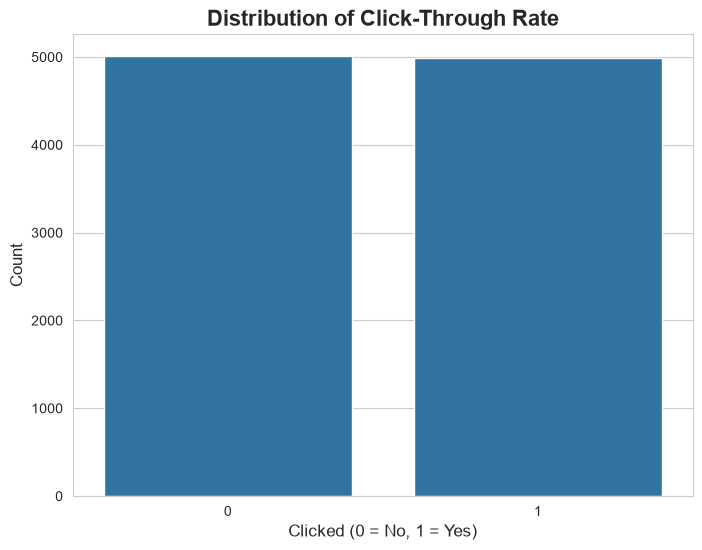

In [7]:
# Target variable distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Clicked')
plt.title('Distribution of Click-Through Rate', fontsize=16, fontweight='bold')
plt.xlabel('Clicked (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)

In [8]:
# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Click rate: {df['Clicked'].mean():.2%}")

<Figure size 1200x800 with 0 Axes>

Click rate: 49.89%


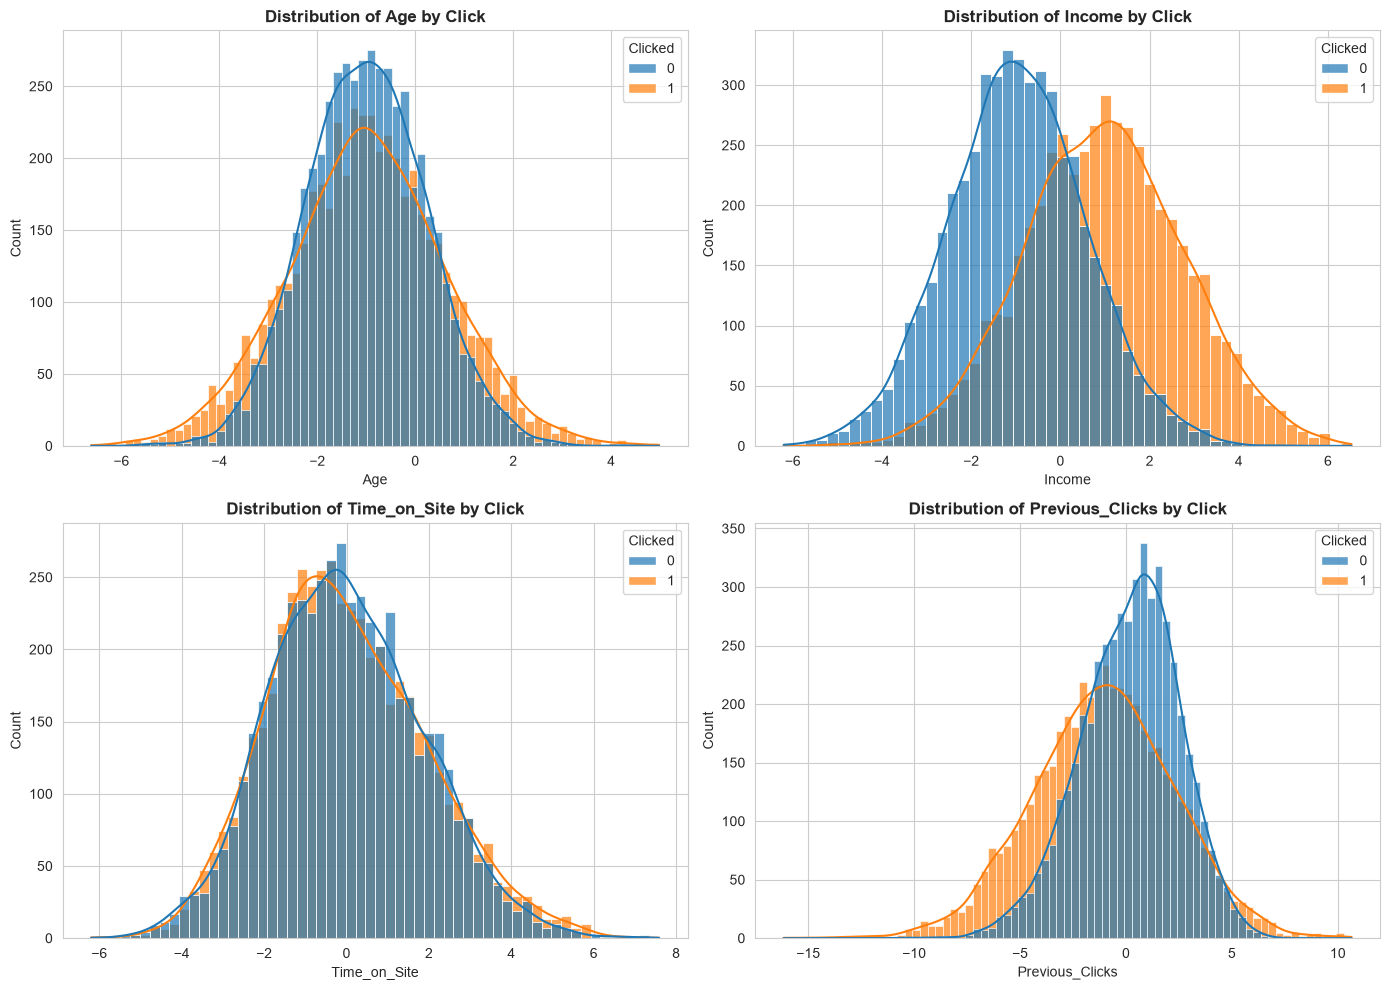

In [9]:
# Numerical features distribution
numerical_cols = ['Age', 'Income', 'Time_on_Site', 'Previous_Clicks']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    sns.histplot(data=df, x=col, hue='Clicked', kde=True, ax=ax, alpha=0.7)
    ax.set_title(f'Distribution of {col} by Click', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [12]:
# Categorical features distribution
categorical_cols = ['Device_Type', 'Ad_Category', 'Gender', 'Time_of_Day']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    # Create cross-tabulation
    crosstab = pd.crosstab(df[col], df['Clicked'], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'Click Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage')
    ax.legend(['Not Clicked', 'Clicked'], title='')
    ax.axhline(y=50, color='r', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

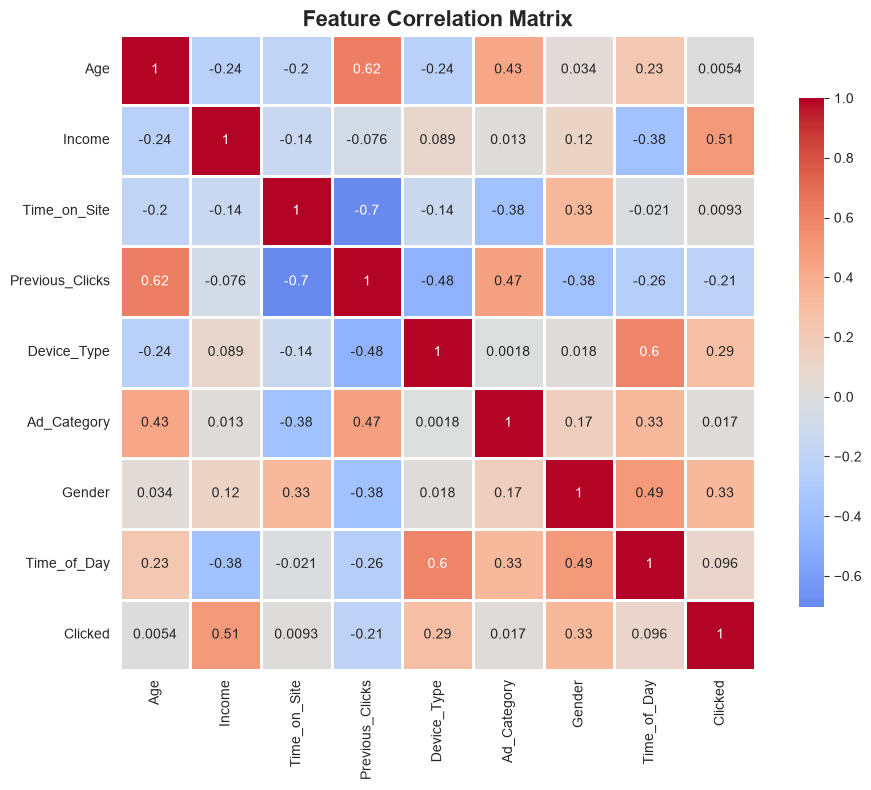

In [13]:
# Correlation analysis
# Convert categorical to numeric for correlation
df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

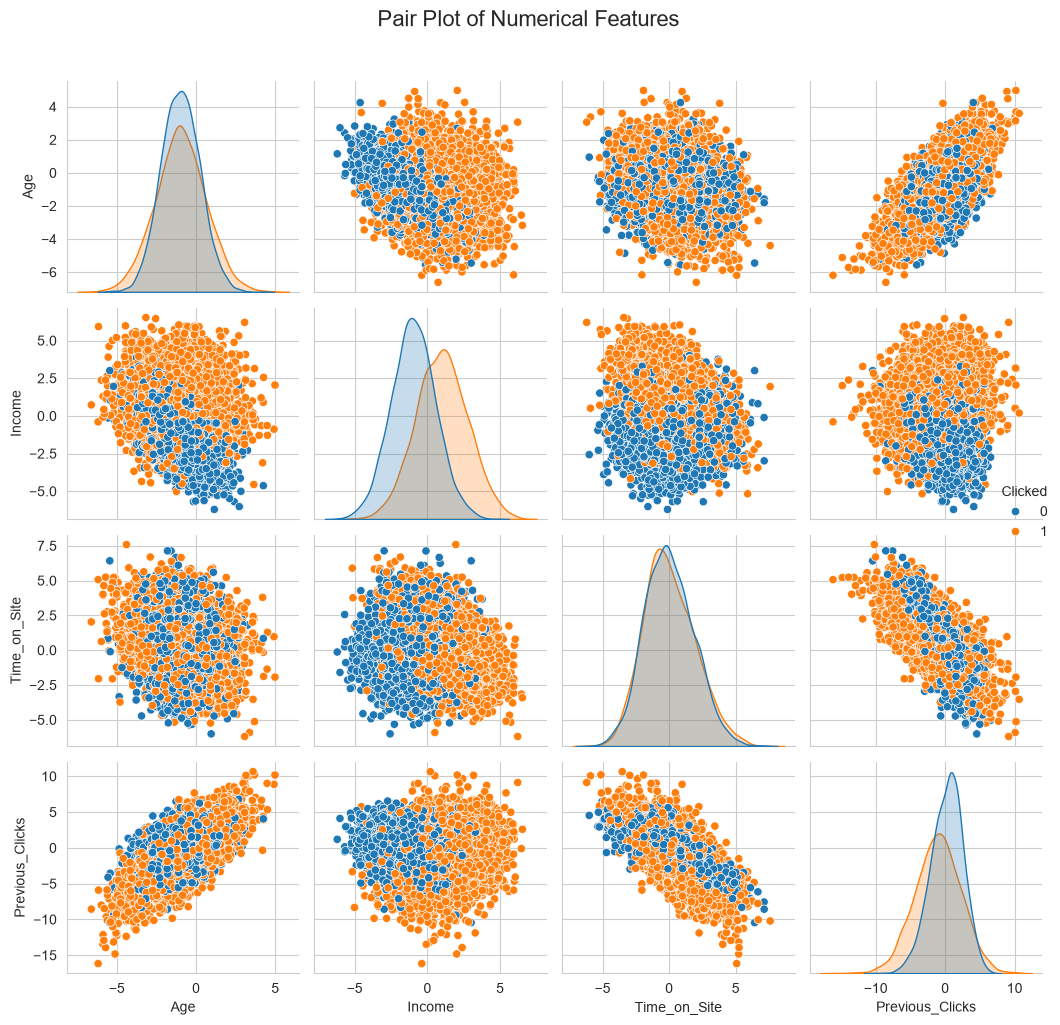

In [16]:
# Pair plot for numerical features
sns.pairplot(df, hue='Clicked', vars=numerical_cols, diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

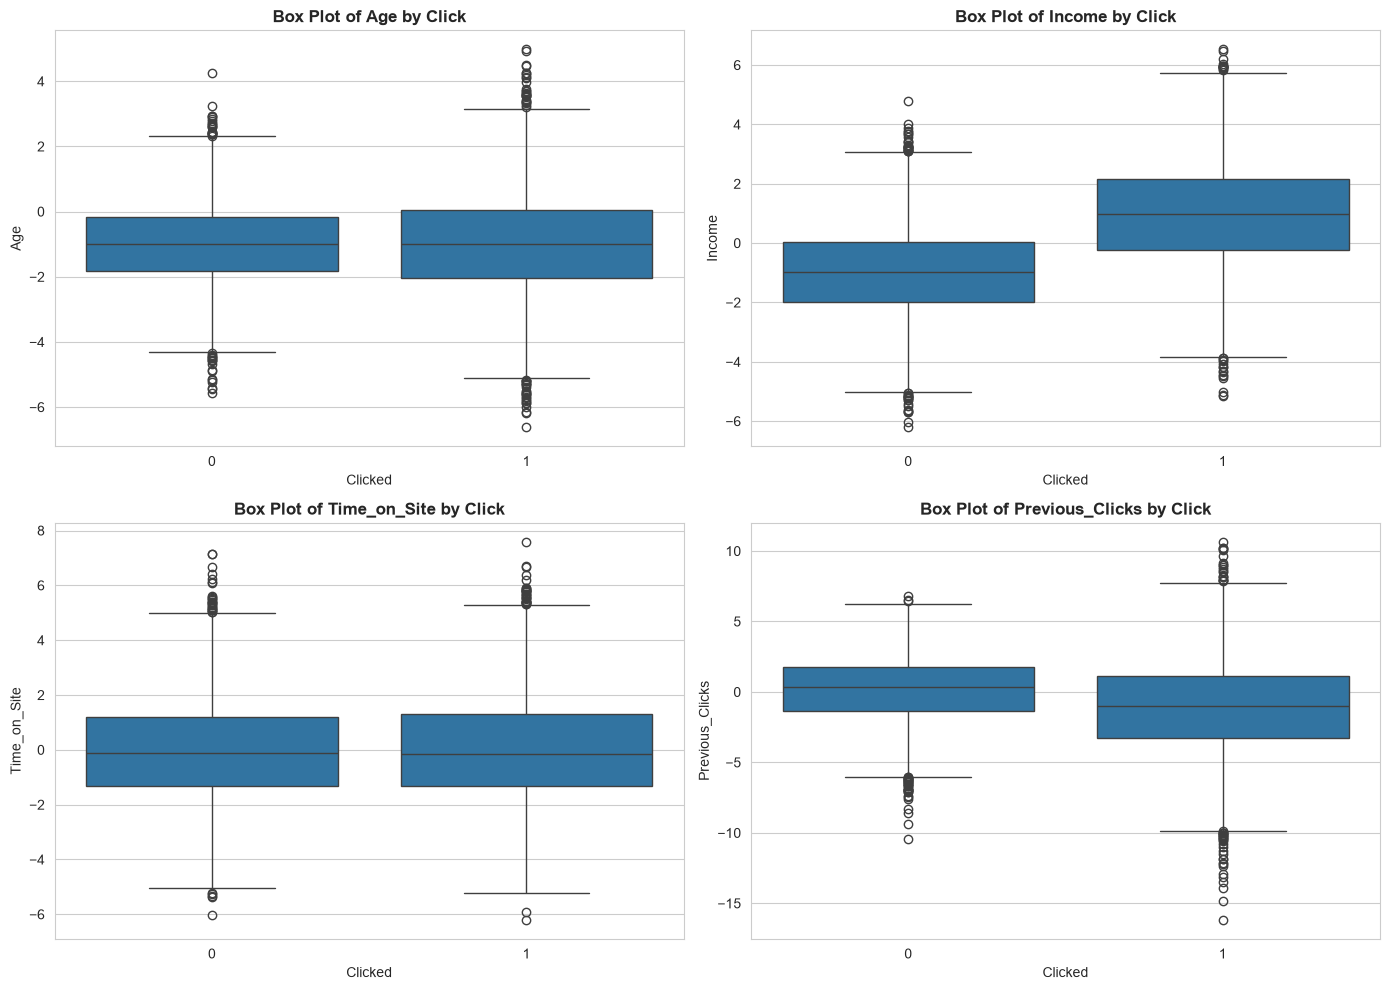

In [15]:
# Box plots to check for outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    sns.boxplot(data=df, y=col, x='Clicked', ax=ax)
    ax.set_title(f'Box Plot of {col} by Click', fontsize=12, fontweight='bold')
    ax.set_xlabel('Clicked')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [17]:
# Save processed data
df.to_csv('../data/processed_data.csv', index=False)
print("Data preprocessing complete! Saved to 'data/processed_data.csv'")

Data preprocessing complete! Saved to 'data/processed_data.csv'
